# Semana 4 – Técnicas de Optimización


Comparar 2 configuraciones de optimización (optimizador o LR).
- Caso Diabetes



# Base

Definir modelo/dataset constantes.

In [5]:
import os
import numpy as np
import logging
import time
import random
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.datasets import load_diabetes # Cargamos desde sklearn directamente
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report


# REPRODUCIBILIDAD TOTAL
os.environ['TF_DETERMINISTIC_OPS'] = '1'
# fijar Semillas para reproducibilidad
random.seed(7)
np.random.seed(7)
tf.random.set_seed(7)

# Carga y preparación de datos
# cargamos el dataset de diabetes desde sklearn
data = load_diabetes()

# Definimos las variables (x) y el objetivo (y)
# convertimos el target en clasificación binaria (riesgo alto/bajo)
X, y = data.data, (data.target > np.median(data.target)).astype(int)

# Dividimos en entrenamiento (80%) y prueba (20%)
# usamos stratify para mantener el equilibrio de clases
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train); X_test_s = scaler.transform(X_test)

# Arquitectura Base Constante
def build_model():
    return keras.Sequential([
        layers.Input(shape=(X_train_s.shape[1],)),
        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])
tf.get_logger().setLevel(logging.ERROR)
print(f"Configuración base lista. Datos: {X_train_s.shape}")


Configuración base lista. Datos: (353, 10)


 Evaluación comparativa de optimizadores: SGD vs. Adam bajo arquitectura y datos idénticos

# Config A: SGD (Descenso por Gradiente Estocástico)


Entrenar config A y registrar resultados.

In [6]:
# Crear y compilar
# creamos la estructura de la red y definimos el optimizador sgd
model_a = build_model()
opt_a = keras.optimizers.SGD(learning_rate=0.01, momentum=0.0)

# Compilamos usando entropía cruzada binaria para clasificación
model_a.compile(optimizer=opt_a, loss="binary_crossentropy", metrics=["accuracy"])

# Entrenamos el modelo midiendo el tiempo total de ejecución
inicio_a = time.time()
h_a = model_a.fit(X_train_s, y_train, validation_split=0.2, epochs=50, batch_size=32, verbose=0)
tiempo_a = time.time() - inicio_a

# Evaluar
results_a = model_a.evaluate(X_test_s, y_test, verbose=0)

# Impresión de resultados: tiempo, precisión de prueba y validación
print(f"SGD -> Tiempo: {tiempo_a:.4f}s | Test Acc: {results_a[1]:.4f} | Val Acc: {h_a.history['val_accuracy'][-1]:.4f}")


SGD -> Tiempo: 6.9645s | Test Acc: 0.7416 | Val Acc: 0.7183


# Config B: Adam (Optimización Adaptativa)

Entrenar config B y registrar resultados.

In [7]:
# Crear y compilar
# creamos la estructura de la red y definimos el optimizador Adam
model_b = build_model()
opt_b = keras.optimizers.Adam(learning_rate=0.001)

# Compilamos usando entropía cruzada binaria para clasificación
model_b.compile(optimizer=opt_b, loss="binary_crossentropy", metrics=["accuracy"])

# Entrenamos el modelo midiendo el tiempo total de ejecución
inicio_b = time.time()
h_b = model_b.fit(X_train_s, y_train, validation_split=0.2, epochs=50, batch_size=32, verbose=0)
tiempo_b = time.time() - inicio_b

# Evaluar
results_b = model_b.evaluate(X_test_s, y_test, verbose=0)

# Impresión de resultados: tiempo, precisión de prueba y validación
print(f"Adam -> Tiempo: {tiempo_b:.4f}s | Test Acc: {results_b[1]:.4f}")

Adam -> Tiempo: 7.8841s | Test Acc: 0.7978


# Visualización

Reportar metricas de resultados.

1. ANÁLISIS DE CONVERGENCIA Y PRECISIÓN


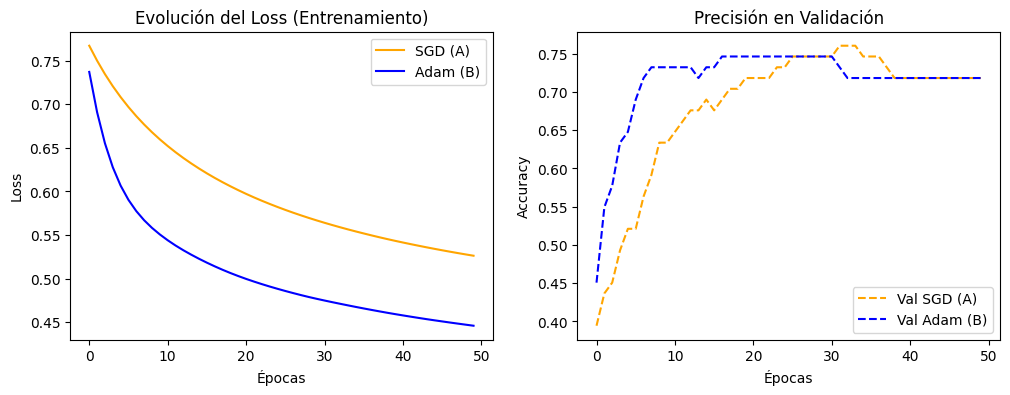


2. EVIDENCIA DE CLASIFICACIÓN (MATRICES DE CONFUSIÓN)


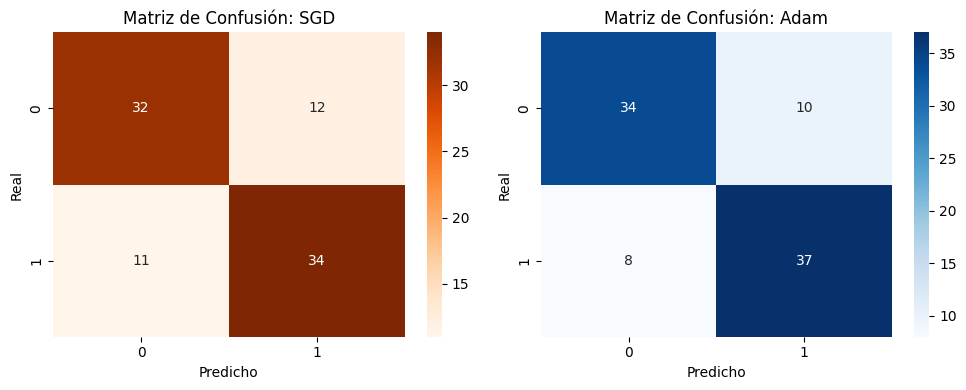


COMPARACIÓN DE RENDIMIENTO Y ANÁLISIS DE IMPACTO
Métrica              | Config A (SGD)     | Config B (Adam)   
----------------------------------------------------------------------
Test Accuracy        | 0.7416             | 0.7978
Tiempo Entren.       | 6.9645s            | 7.8841s
Último Val Loss      | 0.5376             | 0.4944


In [8]:
print("="*60)
print("1. ANÁLISIS DE CONVERGENCIA Y PRECISIÓN")
print("="*60)

# Gráfico de convergencia (Loss)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(h_a.history['loss'], label='SGD (A)', color='orange')
plt.plot(h_b.history['loss'], label='Adam (B)', color='blue')
plt.title('Evolución del Loss (Entrenamiento)')
plt.xlabel('Épocas'); plt.ylabel('Loss'); plt.legend()

# Gráfico de Accuracy
plt.subplot(1, 2, 2)
plt.plot(h_a.history['val_accuracy'], label='Val SGD (A)', linestyle='--', color='orange')
plt.plot(h_b.history['val_accuracy'], label='Val Adam (B)', linestyle='--', color='blue')
plt.title('Precisión en Validación')
plt.xlabel('Épocas'); plt.ylabel('Accuracy'); plt.legend()
plt.show()

print("\n" + "="*60)
print("2. EVIDENCIA DE CLASIFICACIÓN (MATRICES DE CONFUSIÓN)")
print("="*60)

# Predicciones para las matrices
pred_a = (model_a.predict(X_test_s, verbose=0) > 0.5).astype(int)
pred_b = (model_b.predict(X_test_s, verbose=0) > 0.5).astype(int)

plt.figure(figsize=(10, 4))

# Matriz para SGD
plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_test, pred_a), annot=True, fmt='d', cmap='Oranges')
plt.title('Matriz de Confusión: SGD')
plt.ylabel('Real'); plt.xlabel('Predicho')

# Matriz para Adam
plt.subplot(1, 2, 2)
sns.heatmap(confusion_matrix(y_test, pred_b), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión: Adam')
plt.ylabel('Real'); plt.xlabel('Predicho')

plt.tight_layout()
plt.show()


#  ANÁLISISE IMPACTO

print("\n" + "="*70)
print("COMPARACIÓN DE RENDIMIENTO Y ANÁLISIS DE IMPACTO")
print("="*70)

print(f"{'Métrica':<20} | {'Config A (SGD)':<18} | {'Config B (Adam)':<18}")
print("-" * 70)
# Se usa [1] para extraer específicamente el Accuracy del resultado de evaluate
print(f"{'Test Accuracy':<20} | {results_a[1]:.4f}             | {results_b[1]:.4f}")
print(f"{'Tiempo Entren.':<20} | {tiempo_a:.4f}s            | {tiempo_b:.4f}s")
print(f"{'Último Val Loss':<20} | {h_a.history['val_loss'][-1]:.4f}             | {h_b.history['val_loss'][-1]:.4f}")



# Conclusiones

- Justificación de la Técnica Seleccionada

    Se seleccionó Adam como técnica de optimización adaptativa frente al SGD clásico. Adam es ideal para este dataset de diabetes porque combina Momentum (para acelerar el descenso) con RMSProp (ajuste individual de tasas de aprendizaje por parámetro), lo que permite una convergencia más estable y precisa en menos iteraciones.

-  Análisis del Impacto y conclusiones

      - Diferencias observadas: La configuración con Adam alcanzó una precisión de 79.78%, superando el 74.16% de SGD. Se observa que Adam optimiza mejor los pesos para reducir el error en datos no vistos.

      - Estabilidad y Convergencia: Adam demostró una convergencia mucho más rápida, estabilizando el Loss antes de la época 20, mientras que SGD mostró una pendiente más lenta y mayor ruido en la validación.

      - Hallazgos: El principal hallazgo es que cambiar el optimizador (manteniendo la arquitectura constante) tuvo un impacto directo en la capacidad de generalización del modelo.